# Credit Card Fraud Detection Project

This project detects fraudulent credit card transactions
using Machine Learning and Data Analysis techniques.

Features:
1. Data Cleaning
2. Exploratory Data Analysis
3. Fraud vs Non-Fraud Analysis
4. Data Visualization
5. Machine Learning Model Building
6. Fraud Prediction

Author: Disha Kataria


In [ ]:
# Import Libraries
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
df = pd.read_csv('creditcard.csv')

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Missing Values Check
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#Checking duplicate values
df.duplicated().sum()

np.int64(1081)

##### Confidential data, so keeping the duplicates.

### Fraud vs Non-Fraud Count

In [ ]:
# Calculate the number of fraud and genuine transactions
fraud_transactions = df[df['Class'] == 1].shape[0]
fraud_transactions

492

In [ ]:
genuine_transaction = df[df['Class']==0].shape[0]
genuine_transaction

284315

In [ ]:
fraud_percentage = (fraud_transactions/ df.shape[0])*100
fraud_percentage

0.1727485630620034

In [ ]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


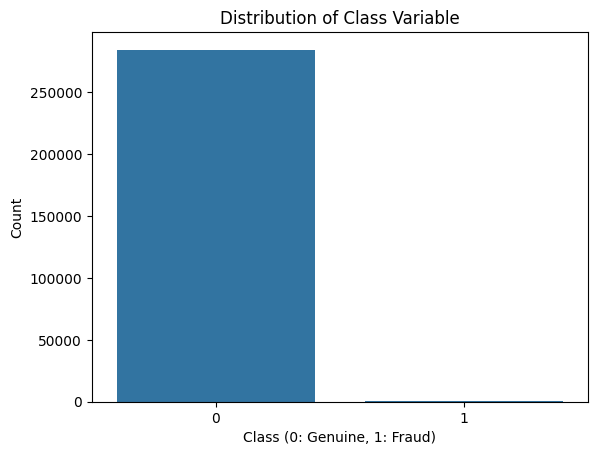

In [ ]:
# Fraud Distribution Visualization
sns.countplot(data = df, x='Class')
plt.title('Distribution of Class Variable')
plt.xlabel('Class (0: Genuine, 1: Fraud)')
plt.ylabel('Count')
plt.show()

([<matplotlib.patches.Wedge at 0x7d3b32dcc140>,
 [Text(-1.0999838024749575, 0.0059694466019511215, 'Genuine'),
  Text(1.099983802996819, -0.005969350438309128, 'Fraud')],
 [Text(-0.5999911649863404, 0.0032560617828824297, '99.83%'),
  Text(0.5999911652709922, -0.0032560093299867964, '0.17%')])

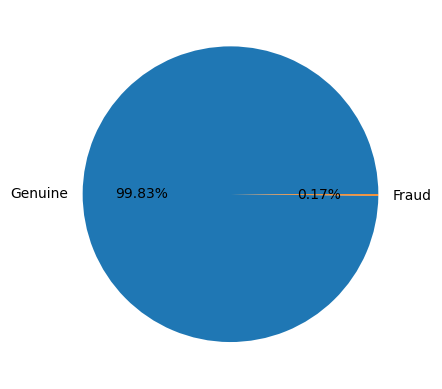

In [ ]:
plt.pie(df['Class'].value_counts(),labels=['Genuine','Fraud'], autopct='%1.2f%%')

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Feature Scaling
scaler = StandardScaler()
df['Normalized_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
#Standardization requires 2D data, therefore reshaped it.

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Normalized_Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,-0.350151
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,-0.254117
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,-0.081839
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,-0.313249


In [ ]:
x = df.drop(columns = ['Time', 'Amount', 'Class'])

In [ ]:
x

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Normalized_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313249


In [ ]:
y = df['Class']

In [ ]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


In [ ]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = 24 )

In [ ]:
# Handle Imbalanced Dataset Using SMOTE
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(x_train, y_train)

In [ ]:
X_train_sm

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Normalized_Amount
0,-5.135521,4.310297,-1.081055,-1.959155,-1.831609,-1.175543,-0.572116,1.434585,2.623566,3.720334,...,1.641730,-0.573225,-0.195409,0.282114,0.398022,0.333418,0.582575,-0.521036,-1.310999,-0.345873
1,1.278730,-0.332093,0.006240,-0.879708,-0.058081,0.282946,-0.463243,0.021814,3.036169,-1.459940,...,-0.139288,-0.209358,-0.140995,-0.249547,-1.365204,0.742287,-0.549455,0.052321,0.005955,-0.241283
2,2.033209,-0.128261,-1.185948,0.217215,0.094261,-0.619116,0.051805,-0.133873,0.321920,0.237768,...,-0.216665,-0.254623,-0.633930,0.295240,-0.398967,-0.304055,0.204375,-0.072668,-0.074245,-0.345313
3,-5.774977,-3.687072,0.769072,4.849130,3.262499,-2.657994,-2.720609,0.784245,-0.137801,0.334377,...,-0.222227,-0.118699,-0.353055,-2.160641,0.834831,-0.109508,0.308668,0.985932,-1.555750,-0.298656
4,-0.494876,0.796197,-0.347333,-0.961746,1.088380,1.381723,0.145276,1.036766,-0.343746,-0.631111,...,-0.314730,-0.082448,-0.109806,0.197217,-1.783410,-0.784920,0.278738,0.184462,0.003782,-0.345313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398051,-10.617890,6.853338,-16.086896,6.599765,-9.254283,-4.449775,-15.187753,3.332249,-4.540663,-14.768148,...,0.140888,1.170625,1.128730,-0.416276,0.562300,-1.189780,-0.424369,-0.831131,-0.090715,-0.337212
398052,-0.780572,-1.458971,-0.885212,5.486163,0.767197,0.266544,1.841273,-0.938392,-0.181388,1.430571,...,0.123847,-0.362734,-0.381828,0.234455,0.842154,-0.609490,0.018961,0.004434,-0.678265,2.144005
398053,0.497521,3.361013,-5.905538,5.565355,1.701533,-2.014935,-0.913063,0.434027,-3.383355,-4.020419,...,0.343447,0.198769,-0.689154,-0.078360,-0.237446,-0.004904,0.064157,0.486419,0.313479,-0.353229
398054,-2.068240,2.168311,-3.078862,1.759976,-1.430375,-1.088684,-2.919291,0.977530,-2.011828,-4.442042,...,0.314310,0.850356,0.724998,-0.389081,-0.408619,0.028011,0.435187,0.266218,0.152214,-0.210944


In [ ]:
Y_train_sm.value_counts()

,count
Class,
0,199028
1,199028


## Decision Tree Model

In [ ]:
decision_tree = DecisionTreeClassifier()

In [ ]:
# Train Decision Tree Model
decision_tree.fit(X_train_sm, Y_train_sm)

DecisionTreeClassifier()

In [ ]:
# Decision Tree Prediction
dt_prediction = decision_tree.predict(x_test)

In [ ]:
# Decision Tree Accuracy
dt_accuracy = accuracy_score(y_test, dt_prediction)
print(f"Decision Tree Accuracy : {dt_accuracy}")

Decision Tree Accuracy : 0.9976358508011188


In [ ]:
# Decision Tree Classification Report
classificationReport = classification_report(y_test, dt_prediction)
print(classificationReport)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85287
           1       0.42      0.74      0.53       156

    accuracy                           1.00     85443
   macro avg       0.71      0.87      0.77     85443
weighted avg       1.00      1.00      1.00     85443



# Model Analysis

The Decision Tree model performs well on fraud detection.
Recall is important in fraud detection because identifying
fraudulent transactions is more critical than avoiding
some false positives.


# Random Forest Model



In [ ]:
# Train Random Forest Model
random_forest = RandomForestClassifier()
random_forest.fit(X_train_sm, Y_train_sm)

RandomForestClassifier()

In [ ]:
# Random Forest Prediction
rf_prediction = random_forest.predict(x_test)

In [ ]:
# Random Forest Accuracy
rf_accuracy = accuracy_score(y_test, rf_prediction)
print(f"The accuracy achieved by random forest is {rf_accuracy}")

The accuracy achieved by random forest is 0.9994499256814484


In [ ]:
# Random Forest Classification Report
print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85287
           1       0.90      0.79      0.84       156

    accuracy                           1.00     85443
   macro avg       0.95      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



# Random Forest Analysis

Random Forest performed better than the Decision Tree model.

Why Random Forest performed better:
- It combines multiple decision trees
- Reduces overfitting
- Gives more stable predictions
- Handles imbalanced datasets more effectively

Model Performance:
- High accuracy achieved
- Better fraud precision
- Good recall for fraud detection

In fraud detection, recall is very important because
missing fraudulent transactions can cause financial loss.

This model successfully identifies most fraudulent
transactions while maintaining strong overall performance.


# Logistic Regression

In [ ]:
log_model = LogisticRegression()

In [ ]:
# Train Logistic Regression Model
log_model.fit(X_train_sm, Y_train_sm)

LogisticRegression()

In [ ]:
# Logistic Regression Prediction
log_prediction = log_model.predict(x_test)

In [ ]:
# Logistic Regression Accuracy
log_accuracy = accuracy_score(y_test, log_prediction)
print(f"The accuracy achieved by logistic regression is {log_accuracy}")

The accuracy achieved by logistic regression is 0.9767213229872547


In [ ]:
# Logistic Regression Classification Report
print(classification_report(y_test, log_prediction))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85287
           1       0.06      0.85      0.12       156

    accuracy                           0.98     85443
   macro avg       0.53      0.91      0.55     85443
weighted avg       1.00      0.98      0.99     85443



# Logistic Regression Analysis

Logistic Regression is a simple and efficient
classification algorithm used for binary prediction problems.

In this project:
- The model was trained on balanced data using SMOTE
- It achieved good recall for fraud detection
- The model successfully identified many fraudulent transactions

However:
- Precision for fraud transactions is low
- This means the model produced more false positives

This happens because fraud datasets are highly imbalanced
and Logistic Regression is a simpler linear model.

Even though the overall accuracy is high,
accuracy alone is not enough in fraud detection.

Important Metrics in Fraud Detection:
- Recall → Detecting maximum fraud cases
- Precision → Reducing false fraud alerts
- F1-score → Balance between precision and recall

This model provides a good baseline for comparison
with advanced models like Decision Tree and Random Forest.


# SVM Model (Kernel : rbf)

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(kernel = 'rbf')

In [ ]:
# Train SVM Model
svm_model.fit(X_train_sm, Y_train_sm)

SVC()

In [ ]:
# SVM Model Prediction
svm_prediction = svm_model.predict(x_test)

In [ ]:
# SVM Model Accuracy
svm_accuracy = accuracy_score(y_test, svm_prediction)
print(f"The accuracy achieved by SVM is {svm_accuracy}")

The accuracy achieved by SVM is 0.989232587807076


In [ ]:
# SVM Model Classification Report
print(classification_report(y_test, svm_prediction))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     85287
           1       0.13      0.84      0.22       156

    accuracy                           0.99     85443
   macro avg       0.56      0.91      0.61     85443
weighted avg       1.00      0.99      0.99     85443



# SVM Model Analysis

Support Vector Machine (SVM) is a powerful classification
algorithm used for both linear and non-linear problems.

In this project:
- SVM was used with the RBF (Radial Basis Function) kernel
- The model handled complex fraud patterns effectively
- It achieved high recall for fraud detection

Model Performance:
- Good overall accuracy
- Better fraud detection compared to Logistic Regression
- Improved balance between precision and recall

However:
- Precision is still lower than Random Forest
- Some false positive fraud predictions are generated

Why RBF Kernel is Used:
- It helps classify non-linear data
- Captures complex relationships between features
- Performs better on complicated datasets

Important Insight:
In fraud detection, detecting fraudulent transactions
(recall) is more important than only maximizing accuracy.

SVM performed better than Logistic Regression
but Random Forest still achieved the best overall results
in this project.
